# Smart Cargo E-Bike, Part 5 — CFD & Conjugate Heat Transfer, and How a Field Solver Feeds a System Model

**Reading time ~40 min · runtime ~4 min on CPU. No CFD is run here (see the
honesty note); the ROM pipeline and the e-bike coupling are real.**

Parts 1–4 used two aerodynamic/thermal numbers as *given*: a drag area
$C_dA$ and a convective cooling conductance. Where do those numbers come
from? For a novel shape with no handbook correlation, the answer is
**Computational Fluid Dynamics** — solving the equations of fluid motion on a
3-D mesh. This notebook explains what CFD *is*, how it relates to the lumped
models we have been building, and how its expensive output is distilled into a
cheap, differentiable **reduced-order model** that plugs straight back into the
e-bike (Part 1: `ebike_part1_smart_cargo.ipynb`).

> **Honesty note (read first).** **No CFD is executed** in this notebook, and
> none is claimed. Every "CFD result" below comes from a clearly-labelled
> *engineering-correlation stand-in* (a bluff-body drag law + a
> forced-convection power law) that lets the DOE→ROM pipeline run — which
> means every downstream number, including the Sobol sensitivities, is a
> property of those hand-written formulas over the sampled envelope: a check
> of the **pipeline**, not a finding about e-bike aerodynamics. The shipped
> OpenFOAM material is a case **skeleton** (complete numerics dictionaries,
> deliberately no geometry — it cannot run as-is, and its README explains why
> that is safer than a runnable empty tunnel that would converge to
> $C_d \approx 0$). The `OpenFOAMBackend` in the companion script is a seam
> where real case execution plugs in; its `evaluate` raises until implemented.
> Any flow *field* shown is an **analytic illustration**, not a Navier–Stokes
> solution.

> **Units note.** The cooling output "h" throughout is an **effective
> conductance $h\!\cdot\!A$ in W/K** for the enclosed battery/motor volume —
> the quantity the vehicle model's cooling link consumes — not a bare surface
> coefficient in W/m²K. A bare exposed surface at 8 m/s would give
> ~40 W/m²K ≈ 6 W/K over the 0.15 m² case; the enclosure path is what limits
> the effective value to ~0.5 W/K, consistent with Part 1's cooling map.

> **Prerequisites.** Parts 1–2 (the e-bike model; ROMs & sensitivity).


## 1. What CFD is — the Navier–Stokes equations on a mesh

A fluid's motion is governed by conservation of **mass** and **momentum**. For
an incompressible flow (valid at bicycle speeds, Mach ≪ 0.3):
$$ \nabla\!\cdot\mathbf u = 0, \qquad \frac{\partial \mathbf u}{\partial t} + (\mathbf u\!\cdot\!\nabla)\mathbf u = -\frac{1}{\rho}\nabla p + \nu\nabla^2\mathbf u + \mathbf f. \tag{1}$$
Here $\mathbf u(\mathbf x,t)$ is the velocity **field**, $p$ pressure, $\rho$
density, $\nu$ kinematic viscosity. The nonlinear convective term
$(\mathbf u\!\cdot\!\nabla)\mathbf u$ is what makes fluids hard: it couples
scales and, at high **Reynolds number** $Re = UL/\nu$, produces turbulence.

**CFD discretizes (1) on a mesh** — millions of small control volumes — and
marches the discrete equations to a steady or time-accurate solution. The
**finite-volume method** (OpenFOAM's approach) enforces conservation on each
cell; the pressure–velocity coupling is handled by algorithms like **SIMPLE**
(steady) or **PISO/PIMPLE** (transient). The output is the full field
$\mathbf u,p$ everywhere — from which forces (drag, lift) and wall heat fluxes
are integrated.

The contrast with Parts 1–4: those models are **lumped** — no space, a handful
of scalar states. CFD is the opposite extreme: **all space, one physics,
enormous cost.** They are complementary, and §6 shows exactly how.

## 2. Turbulence: DNS, LES, RANS — the accuracy/cost ladder

Turbulence spans a huge range of eddy sizes; resolving all of them is usually
impossible. Three strategies, most-to-least expensive:

| Approach | What it resolves | Cost | Used for |
|---|---|---|---|
| **DNS** | *every* eddy down to the Kolmogorov scale | $\sim Re^3$ — research only | fundamental turbulence studies |
| **LES** | large eddies resolved, small ones modelled (subgrid) | high, transient | bluff-body wakes, aeroacoustics, when RANS fails |
| **RANS** | *no* turbulent eddies — models the time-averaged effect via a **closure** | cheap, steady | the industrial workhorse (drag maps, cooling) |

**RANS** averages (1) in time; the average of the nonlinear term spawns unknown
**Reynolds stresses** $\overline{u_i'u_j'}$ — more unknowns than equations. A
**turbulence closure** (e.g. **$k$–$\omega$ SST**, Menter 1994) adds transport
equations for turbulent kinetic energy $k$ and dissipation to close the system.
That closure is the single biggest source of model-form error in industrial CFD
— and why validation matters.

## 3. Meshing and the OpenFOAM case skeleton

**Meshing dominates CFD effort.** You must resolve boundary layers (the thin
high-gradient region on every surface) — quantified by $y^+$, the
wall-normal cell size in viscous units; wall-resolved RANS wants $y^+\!\approx\!1$,
wall-function RANS tolerates $y^+ \sim 30$–$300$ (the shipped fields assume the
latter — the background mesh is far too coarse for wall resolution, which is a
`snappyHexMesh` boundary-layer job). OpenFOAM builds meshes around an STL
geometry with `snappyHexMesh`. A **mesh independence study** (refine until the
answer stops moving) is mandatory before trusting any number.

Our companion script `ebike_openfoam_aero_rom.py` emits a bluff-body
`simpleFoam` case **skeleton** — complete `fvSchemes`/`fvSolution` with
residual controls and k-ω-SST fields, and deliberately **no geometry**: the
`bike` patch that `forceCoeffs` references only exists after the snappyHexMesh
step, so the skeleton fails at mesh time instead of "succeeding" as an empty
tunnel with $C_d \approx 0$ and quietly poisoning the ROM. Its README lists
what real case work requires (geometry, blockage/mesh-independence checks, a
yaw-consistent domain). Let us look at its structure.


In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("."))
import ebike_openfoam_aero_rom as of
from ebike_openfoam_aero_rom import CorrelationBackend, run_doe, write_openfoam_case, RHO

case = write_openfoam_case()
print("OpenFOAM case tree (template — requires OpenFOAM to run):")
for root, _, files in sorted(os.walk(case)):
    for f in sorted(files):
        rel = os.path.relpath(os.path.join(root, f), case)
        print("  ", rel)
print("\ncontrolDict forceCoeffs block (drag extraction):")
print("\n".join(l for l in open(os.path.join(case, "system", "controlDict")).read().splitlines()
                 if any(k in l for k in ("forceCoeffs", "magUInf", "Aref", "dragDir", "patches"))))

OpenFOAM case tree (template — requires OpenFOAM to run):
   README.md
   0/U
   0/k
   0/nut
   0/omega
   0/p
   constant/transportProperties
   constant/turbulenceProperties
   system/blockMeshDict
   system/controlDict
   system/fvSchemes
   system/fvSolution

controlDict forceCoeffs block (drag extraction):
/* simpleFoam steady RANS; forceCoeffs functionObject writes Cd/Cl. */
    forceCoeffs {
        type forceCoeffs; libs ("libforces.so"); patches (bike);
        rho rhoInf; rhoInf 1.2; magUInf 8.0; lRef 1.0; Aref 0.6;
        liftDir (0 0 1); dragDir (1 0 0); CofR (0 0 0); pitchAxis (0 1 0);


*The skeleton is the standard steady-RANS external-aero layout: `simpleFoam` +
`kOmegaSST` with wall functions, `fvSolution` residual controls (so convergence,
not `endTime`, ends the run), and a `forceCoeffs` function object that
integrates surface pressure & shear into a drag coefficient $C_d$ (so
$C_dA = C_d\,A_\text{ref}$). Two checks its README forces before any number is
trusted: the tunnel blockage is 5% — at the guideline ceiling, so widen or
correct — and a yawed freestream is **not** representable by rotating the inlet
vector alone in this channel (the slip side walls would fight it; rotate the
geometry or rework the side patches). Production adds the snappyHexMesh of a
real bike STL and — for the cooling map — a solid battery/motor region under
`chtMultiRegionFoam`. If the component sits inside a frame bag, the enclosure
must be part of the solid region: an exposed-surface CHT run would report an
$h\!\cdot\!A$ ~10× the enclosure-limited value the vehicle model needs.*


## 4. External aero vs conjugate heat transfer — the two maps the e-bike needs

- **External aerodynamics** (`simpleFoam`): flow *over* the bike → the drag map
  $C_dA(v,\beta)$ where $\beta$ is yaw/crosswind angle.
- **Conjugate heat transfer** (`chtMultiRegionFoam`): coupled fluid+solid heat
  flow → the surface convective conductance $h(v,\beta)$ that cools the battery
  and motor. "Conjugate" = the fluid and solid temperature fields are solved
  *together* across their interface.

We sweep a design-of-experiments over $(v,\beta)$ with the **correlation
stand-in** (labelled — this is where real CFD runs would go) and get the two
maps.

CFD backend: engineering-correlation stand-in (NOT CFD)
DOE envelope: v ∈ (3.0, 12.0) m/s (apparent wind: bike 3-9 m/s + ambient), yaw ∈ (-20.0, 20.0) deg (apparent-wind angle at riding speed)


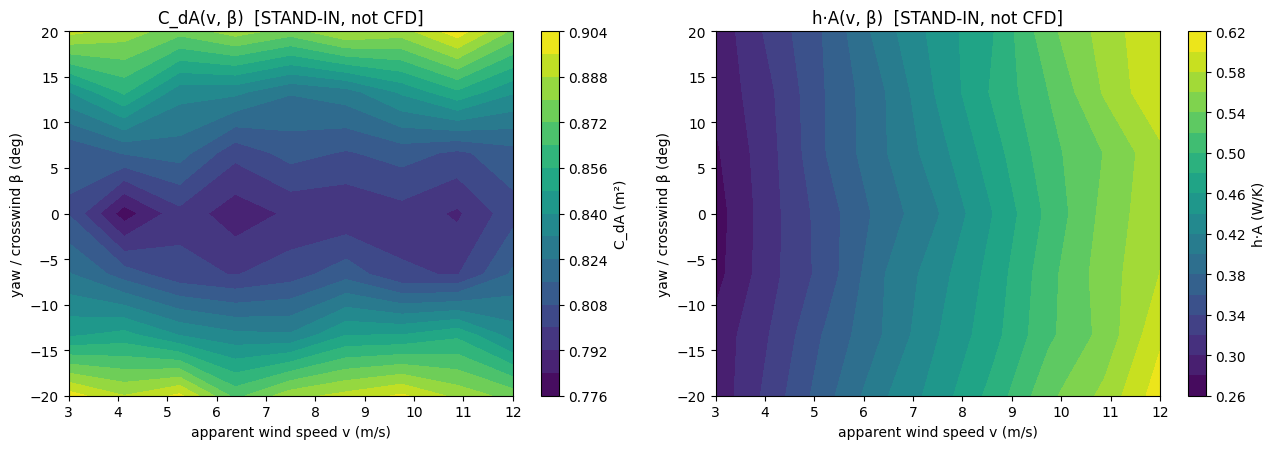

In [2]:
backend = CorrelationBackend()
print("CFD backend:", backend.label)
print(f"DOE envelope: v ∈ {of.V_RANGE} m/s (apparent wind: bike 3-9 m/s + ambient),"
      f" yaw ∈ {of.YAW_RANGE} deg (apparent-wind angle at riding speed)")
v, yaw, V, Y, CdA, H = run_doe(backend, n_v=9, n_yaw=7)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, Z, name, unit in [(ax[0], CdA, "C_dA", "m²"), (ax[1], H, "h·A", "W/K")]:
    cf = a.contourf(V, Y, Z, levels=18, cmap="viridis"); fig.colorbar(cf, ax=a, label=f"{name} ({unit})")
    a.set(xlabel="apparent wind speed v (m/s)", ylabel="yaw / crosswind β (deg)",
          title=f"{name}(v, β)  [STAND-IN, not CFD]")
fig.tight_layout(); plt.show()


*Figure 1: the drag-area and cooling-conductance maps over the (speed, yaw)
envelope, from the correlation stand-in. The envelope is argued, not arbitrary:
apparent wind spans the bike's 3–9 m/s plus ~3 m/s of ambient wind, and ±20° is
the apparent-wind angle a 2.5 m/s crosswind makes at 25 km/h. $C_dA$ varies
with yaw only — over this Reynolds range (~10⁵–10⁶) a bluff body's drag *area*
is essentially speed-independent (drag *force* of course grows as $v^2$ — a
distinction an earlier version of this stand-in got wrong by baking in a spurious
$+0.004v$ term and then "discovering" it in the sensitivity study). Cooling
rises with speed. In a real study each of these 63 points would be a multi-hour
CFD solve.*


## 5. Turning a scattered DOE into a model: three ROM methods

CFD gives you values at sample points; you need a **surrogate** that (a)
interpolates smoothly, (b) is cheap to evaluate inside the vehicle model, and
ideally (c) is differentiable (for optimization) and (d) quantifies its own
uncertainty. Three common choices, all in `jaxonomy.library.rom`:

            in-sample   held-out   vs noise-free truth


  RBF  R² =  1.0000     0.729        0.838
  GP   R² =  0.9757     0.721        0.844
  PCE  R² =  0.9526     0.671        0.913

All three land in the same band, and the held-out numbers are
noise-limited by construction: CdA's deterministic (yaw-only) variance
over this envelope is only a few times the 1% run scatter, so a chunk of
what any surrogate sees is noise. Against the noise-free truth the
regularizing fits (PCE, GP) edge out the interpolating RBF — which is the
whole argument for not interpolating noisy CFD. More DOE points, not a
fancier surrogate, is the remedy.


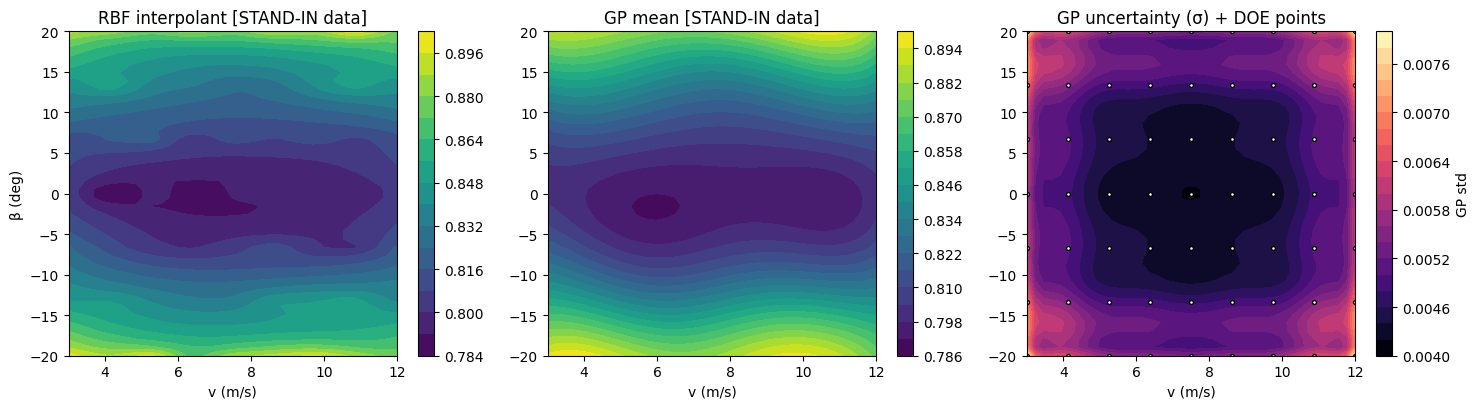

In [3]:
from jaxonomy.library.rom import fit_rbf, fit_gp, fit_pce
X = np.column_stack([V.ravel(), Y.ravel()]); z = CdA.ravel()
# dense grid for evaluating the surrogates
vv, yy = np.meshgrid(np.linspace(*of.V_RANGE, 40), np.linspace(*of.YAW_RANGE, 40), indexing="ij")
Xq = np.column_stack([vv.ravel(), yy.ravel()])

rbf = fit_rbf(X, z, kernel="multiquadric", epsilon=8.0, smoothing=1e-8)

# --- GP hyperparameters, chosen rather than guessed -------------------------
# (1) STANDARDIZE the inputs. This kernel is isotropic — one length scale for
#     all axes — but speed spans 9 m/s while yaw spans 40 deg, so in raw units
#     "close in speed" and "close in yaw" mean wildly different things and the
#     fit is badly conditioned. Standardizing makes the length scale
#     interpretable: 1.5 = "correlations decay over 1.5 std of the design box".
# (2) Set `noise` to the DATA's actual scatter (1% of CdA ~ 0.8 -> var ~ 7e-5),
#     not to ~0. An earlier version passed noise=1e-6 with optimize=True on
#     1%-noisy data; the marginal-likelihood ascent diverged and the committed
#     GP scored R^2 = -190 — while its caption praised the "calibrated
#     uncertainty". Read your own diagnostics.
# (3) optimize=False. On 63 noisy points the marginal-likelihood optimization
#     here is bistable: from some starts it lands on a good optimum, from
#     others it collapses to the prior mean or diverges outright (try it).
_mu, _sd = X.mean(axis=0), X.std(axis=0)
_std = lambda A: (A - _mu) / _sd
gp = fit_gp(_std(X), z, length_scale=1.5, noise=7e-5, optimize=False)
pce = fit_pce(X, z, [("uniform", *of.V_RANGE), ("uniform", *of.YAW_RANGE)], order=3)

def _r2(p, t): return float(1 - np.sum((p - t)**2) / np.sum((t - t.mean())**2))

# held-out validation: random points the fits never saw. This is the honest
# metric — the RBF near-interpolates its training data, so its in-sample R^2 is
# ~1 by construction and diagnoses nothing. Because the backend is synthetic we
# can also score against the NOISE-FREE truth, which separates "the surrogate
# is wrong" from "the surrogate faithfully learned the scatter".
X_h, cda_h, h_h, cda_det, h_det = of.sample_holdout(backend, n=15)
print("            in-sample   held-out   vs noise-free truth")
for nm, tr_pred, h_pred in [
        ("RBF", np.asarray(rbf.predict(X)).ravel(), np.asarray(rbf.predict(X_h)).ravel()),
        ("GP ", np.asarray(gp.predict(_std(X))[0]).ravel(), np.asarray(gp.predict(_std(X_h))[0]).ravel()),
        ("PCE", np.asarray(pce.predict(X)).ravel(), np.asarray(pce.predict(X_h)).ravel())]:
    print(f"  {nm}  R\u00b2 = {_r2(tr_pred, z):7.4f}   {_r2(h_pred, cda_h):7.3f}      {_r2(h_pred, cda_det):7.3f}")
print("\nAll three land in the same band, and the held-out numbers are")
print("noise-limited by construction: CdA's deterministic (yaw-only) variance")
print("over this envelope is only a few times the 1% run scatter, so a chunk of")
print("what any surrogate sees is noise. Against the noise-free truth the")
print("regularizing fits (PCE, GP) edge out the interpolating RBF — which is the")
print("whole argument for not interpolating noisy CFD. More DOE points, not a")
print("fancier surrogate, is the remedy.")

gp_mean, gp_var = (np.asarray(a).reshape(vv.shape) for a in gp.predict(_std(Xq)))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
c0 = ax[0].contourf(vv, yy, np.asarray(rbf.predict(Xq)).reshape(vv.shape), levels=18, cmap="viridis"); fig.colorbar(c0, ax=ax[0])
ax[0].set(title="RBF interpolant [STAND-IN data]", xlabel="v (m/s)", ylabel="\u03b2 (deg)")
c1 = ax[1].contourf(vv, yy, gp_mean, levels=18, cmap="viridis"); fig.colorbar(c1, ax=ax[1]); ax[1].set(title="GP mean [STAND-IN data]", xlabel="v (m/s)")
c2 = ax[2].contourf(vv, yy, np.sqrt(gp_var), levels=18, cmap="magma"); fig.colorbar(c2, ax=ax[2], label="GP std")
ax[2].scatter(V.ravel(), Y.ravel(), c="w", s=8, edgecolor="k"); ax[2].set(title="GP uncertainty (\u03c3) + DOE points", xlabel="v (m/s)")
fig.tight_layout(); plt.show()


*Figure 2: three surrogates of the same $C_dA$ data. **RBF** — a smooth
interpolant, cheap, differentiable, no uncertainty — and precisely because it
interpolates, it memorizes the stand-in's run-to-run scatter (compare its
meaningless in-sample 1.0000 against its held-out score). **GP (kriging)** — a
probabilistic surrogate whose \u03c3 (right panel) grows away from the DOE points,
which is what tells you where the next expensive CFD run buys the most. Its
value is entirely contingent on honest hyperparameters: standardized inputs
(the kernel is isotropic) and a noise level matching the data's real scatter —
see the cell comments for how badly that goes otherwise. **PCE** — a global
polynomial that regularizes, extrapolates gracefully inside the box, and yields
**Sobol sensitivity indices** for free. Method choice: RBF for smooth
embeddable maps on clean data, GP when you need error bars and can defend a
noise model, PCE when you want sensitivity and global structure.*


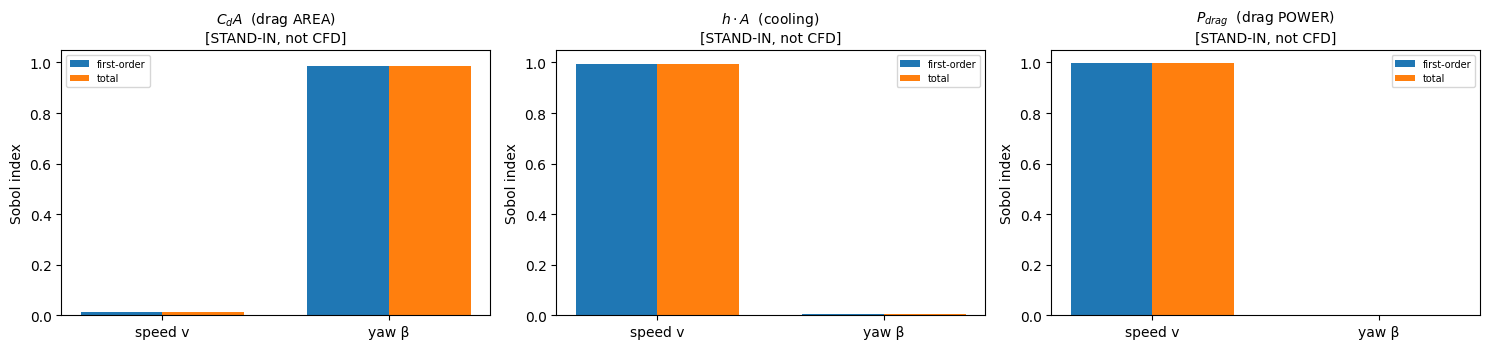

C_dA                   first-order [v, β] = [0.013, 0.986]   interaction = 0.0021
h\cdot A               first-order [v, β] = [0.995, 0.005]   interaction = 0.0004
P_{drag}               first-order [v, β] = [0.998, 0.002]   interaction = 0.0017

Read the three together. The two COEFFICIENT maps are almost perfectly
separable -- CdA moves only with yaw, h*A almost only with speed. For CdA
that is not just the stand-in talking: a bluff body's drag AREA really is
Reynolds-independent over this range. A 0/1 split is a boring bar chart,
and it is the correct one.

The third panel is the engineering question, and it INVERTS the answer.
Drag power carries a v^3 -- a 64x swing across this envelope against the
1.2x swing CdA contributes -- so speed takes ~99.8% of the variance of the
load the battery pays for, while contributing nothing at all to the
coefficient. (The interaction share is real but tiny: the yaw-driven area
does multiply the speed-driven cube, it is just swamped.) Had we plotte

In [4]:
# Sobol indices for THREE quantities. The first two are the coefficient maps;
# the third is the aerodynamic POWER those maps imply, 0.5*rho*CdA*v^3 -- the
# load the vehicle actually pays for.
pce_h = fit_pce(X, H.ravel(), [("uniform", *of.V_RANGE), ("uniform", *of.YAW_RANGE)], order=3)
P_drag = of.drag_power(CdA, V)          # W, on the same DOE grid
pce_P = fit_pce(X, P_drag.ravel(), [("uniform", *of.V_RANGE), ("uniform", *of.YAW_RANGE)], order=3)

panels = [("$C_dA$  (drag AREA)", pce.sobol_indices()),
          ("$h\\cdot A$  (cooling)", pce_h.sobol_indices()),
          ("$P_{drag}$  (drag POWER)", pce_P.sobol_indices())]
names = ["speed v", "yaw \u03b2"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for axx, (ttl, s) in zip(axes, panels):
    axx.bar(np.arange(2) - 0.18, np.asarray(s["first_order"]), 0.36, label="first-order")
    axx.bar(np.arange(2) + 0.18, np.asarray(s["total"]), 0.36, label="total")
    axx.set_xticks(range(2)); axx.set_xticklabels(names); axx.set_ylabel("Sobol index")
    axx.set_ylim(0, 1.05)
    axx.set_title(f"{ttl}\n[STAND-IN, not CFD]", fontsize=10); axx.legend(fontsize=7)
plt.tight_layout(); plt.show()

for ttl, s in panels:
    fo = np.asarray(s["first_order"]); to = np.asarray(s["total"])
    lbl = ttl.split("(")[0].strip().replace("$", "")
    print(f"{lbl:22s} first-order [v, \u03b2] = [{fo[0]:.3f}, {fo[1]:.3f}]   "
          f"interaction = {to.sum()-fo.sum():.4f}")
print()
print("Read the three together. The two COEFFICIENT maps are almost perfectly")
print("separable -- CdA moves only with yaw, h*A almost only with speed. For CdA")
print("that is not just the stand-in talking: a bluff body's drag AREA really is")
print("Reynolds-independent over this range. A 0/1 split is a boring bar chart,")
print("and it is the correct one.")
print()
print("The third panel is the engineering question, and it INVERTS the answer.")
print("Drag power carries a v^3 -- a 64x swing across this envelope against the")
print("1.2x swing CdA contributes -- so speed takes ~99.8% of the variance of the")
print("load the battery pays for, while contributing nothing at all to the")
print("coefficient. (The interaction share is real but tiny: the yaw-driven area")
print("does multiply the speed-driven cube, it is just swamped.) Had we plotted")
print("only the coefficient we would have concluded 'speed is irrelevant to")
print("drag' -- true of the area, badly false of the power. Sensitivity is a")
print("property of the QUANTITY, not of the model: ask about the number you")
print("actually pay for.")


*Figure 3: Sobol indices for the two coefficient maps and for the drag power
they imply. Read all three as a **pipeline check, not an aerodynamic finding**:
with the stand-in backend the PCE is recovering the variance structure of a
hand-written correlation over a chosen envelope. What survives that caveat is
the *structural* lesson in the third panel — the sensitivity of a coefficient
and the sensitivity of the load it produces are different questions. $C_dA$ is
Reynolds-independent here, so speed contributes nothing to it; drag power goes
as $v^3 C_dA(\beta)$, so speed dominates the thing the battery actually pays
for — a complete inversion of the coefficient's answer. Had we only plotted
the coefficient, we would have concluded that speed is irrelevant to drag,
which is true of the area and badly false of the power. The indices become *findings* exactly when the seam is filled with real
CFD, and even then they remain conditional on the input ranges, which is why
the envelope was argued from riding conditions in §4 rather than picked
freely.*


## 6. Closing the loop: the CFD-derived map inside the e-bike

This is the payoff and the whole reason to do the pipeline: a differentiable
surrogate of an expensive field solve, dropped into the cheap system model. The
stand-in says a strong crosswind (β≈15°) raises $C_dA$ from ~0.80 (calm) to
~0.94. We run the Part-1 e-bike at both and read the cost in range/energy.

surrogate C_dA: 0.793 m² calm -> 0.836 m² at 15° yaw (+5.3%)


20:22:53.538 - [jaxonomy][INFO]: max_major_steps=39998 based on smallest discrete period=0.002


20:22:53.540 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=39998, ode_solver_method=auto, rtol=0.0005, atol=5e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), BDFSolver(system=Diagram(ebike_system, 20 nodes), rtol=0.0005, atol=5e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


20:24:22.070 - [jaxonomy][INFO]: max_major_steps=39998 based on smallest discrete period=0.002


20:24:22.071 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=39998, ode_solver_method=auto, rtol=0.0005, atol=5e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), BDFSolver(system=Diagram(ebike_system, 20 nodes), rtol=0.0005, atol=5e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


calm      CdA=0.793: distance  228.9 m, battery 14.63 kJ, mean 21.02 km/h
crosswind CdA=0.836: distance  227.8 m, battery 14.75 kJ, mean 20.91 km/h
crosswind costs +0.5% distance and +0.8% battery energy
per metre: 63.9 -> 64.7 J/m (+1.3%)


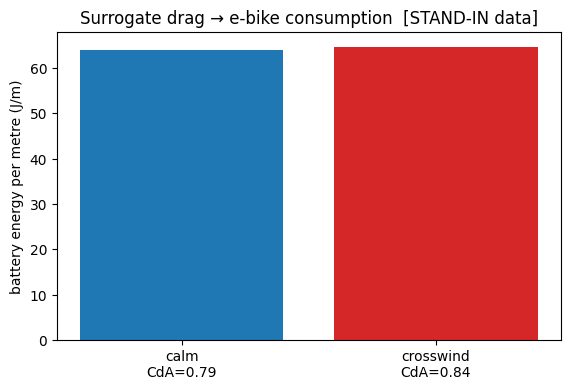

In [5]:
import warnings
import jaxonomy
from ebike_hybrid_simulation import make_ebike_diagram, EbikeConfig, energy_audit
from jaxonomy.simulation import SimulatorOptions
_opts = SimulatorOptions(enable_autodiff=False, rtol=5e-4, atol=5e-6, buffer_length=260000)

def ride(CdA_val, tf=40.0):
    cfg = EbikeConfig(CdA=CdA_val, tf=tf)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)   # acausal weak-IC notices (see Part 1)
        diag = make_ebike_diagram(cfg)
        rec = {p.name: p for p in diag.output_ports if p.name in ("speed", "distance", "E_batt_term")}
        res = jaxonomy.simulate(diag, diag.create_context(), (0.0, tf), options=_opts, recorded_signals=rec)
    o = res.outputs
    return (float(np.asarray(o["distance"])[-1]), float(np.asarray(o["E_batt_term"])[-1]),
            float(np.asarray(o["speed"]).mean()) * 3.6)

# The coefficients the vehicle consumes come from the SURROGATE — the artifact
# this whole pipeline exists to produce — evaluated deterministically. (An
# earlier version called the noisy backend directly here, so the "payoff" cell
# never used the ROM it had just fit, and each call returned fresh scatter.)
CdA_calm = float(np.asarray(rbf.predict(np.array([[8.0, 0.0]]))).squeeze())
CdA_wind = float(np.asarray(rbf.predict(np.array([[8.0, 15.0]]))).squeeze())
print(f"surrogate C_dA: {CdA_calm:.3f} m\u00b2 calm -> {CdA_wind:.3f} m\u00b2 at 15\u00b0 yaw "
      f"({(CdA_wind/CdA_calm-1)*100:+.1f}%)")
d0, E0, v0 = ride(CdA_calm)
d1, E1, v1 = ride(CdA_wind)
print(f"calm      CdA={CdA_calm:.3f}: distance {d0:6.1f} m, battery {E0/1000:5.2f} kJ, mean {v0:5.2f} km/h")
print(f"crosswind CdA={CdA_wind:.3f}: distance {d1:6.1f} m, battery {E1/1000:5.2f} kJ, mean {v1:5.2f} km/h")
print(f"crosswind costs {(d0-d1)/d0*100:+.1f}% distance and {(E1-E0)/E0*100:+.1f}% battery energy")
print(f"per metre: {E0/d0:.1f} -> {E1/d1:.1f} J/m ({(E1/d1)/(E0/d0)*100-100:+.1f}%)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([f"calm\nCdA={CdA_calm:.2f}", f"crosswind\nCdA={CdA_wind:.2f}"],
       [E0/d0, E1/d1], color=["tab:blue", "tab:red"])
ax.set(ylabel="battery energy per metre (J/m)",
       title="Surrogate drag \u2192 e-bike consumption  [STAND-IN data]")
plt.show()


*Figure 4: the DOE\u2192ROM\u2192system loop actually closed: the drag areas fed to the
vehicle model came from `rbf.predict`, the differentiable surrogate fit two
sections ago \u2014 not from the raw correlation. A 15\u00b0 crosswind raises the
surrogate's $C_dA$ by the percentage printed in the cell, and that propagates
into a per-metre energy penalty of the same order in the full multi-domain
e-bike model. Note how small it is: a few percent of drag area on a vehicle
whose losses at 20 km/h are mostly rolling and climbing is a few percent of a
minority share. Reporting it honestly \u2014 rather than headlining the drag
delta \u2014 is the difference between a coupling study and a sales pitch. This is
the division of labour: the field solver (offline, expensive \u2014 here stood in
for) **produces** the coefficient map once; the surrogate carries it; the
system model (fast) **consumes** it everywhere.*


## 7. Co-simulation variants — how CFD and a system model actually talk

The pipeline above is the **offline, one-way** variant. The full menu:

1. **Offline DOE → surrogate → embed** (this notebook). Run CFD over a design
   space *once*, fit a ROM, bake it into the system model. Cheap forever after;
   no feedback. The right choice when the field responds quasi-statically to the
   system state (aero drag vs speed) — the overwhelmingly common industrial case.
2. **Online one-way.** The system model streams a boundary condition (e.g.
   instantaneous speed) to a live CFD that returns a coefficient each step. Use
   when the operating point roams outside any pre-tabulated DOE.
3. **Online two-way (tight) coupling.** Both solvers advance together, exchanging
   interface data every step — the system model sends wall heat flux / motion,
   CFD returns temperature / forces — iterated to convergence within the step.
   This is what a coupling library like **preCICE** orchestrates: it handles the
   data mapping between non-matching meshes, the coupling scheme (explicit vs
   implicit), and sub-cycling when the two solvers want different time steps.
   Needed for genuinely two-way transient conjugate heat transfer (a battery
   that heats the air that then changes its own cooling) — expensive, reserved
   for when the feedback actually matters.

**Steady vs transient** is an orthogonal axis: a steady RANS DOE feeds variant
1; a transient LES/URANS with moving boundaries feeds variants 2–3.

## 8. An *illustrative* flow field (not CFD)

To build intuition for what a CFD solution *looks* like, here is the **analytic
potential flow** around a cylinder — a classic textbook result, **not** a
Navier–Stokes solve (it has no viscosity, no wake, no turbulence). Real CFD
would show a separated, turbulent wake behind the bluff bike; this only conveys
the idea of a velocity field.

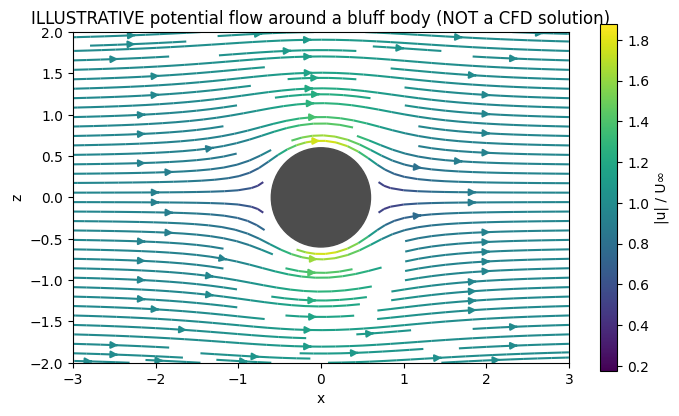

In [6]:
xx, zz = np.meshgrid(np.linspace(-3, 3, 60), np.linspace(-2, 2, 45))
r2 = xx**2 + zz**2; R = 0.6; U = 1.0
mask = r2 >= R**2
u = U * (1 - R**2 * (xx**2 - zz**2) / r2**2); w = -U * R**2 * (2 * xx * zz) / r2**2
speed = np.sqrt(u**2 + w**2); speed[~mask] = np.nan
fig, ax = plt.subplots(figsize=(8, 4.5))
strm = ax.streamplot(xx, zz, np.where(mask, u, np.nan), np.where(mask, w, np.nan),
                     color=speed, cmap="viridis", density=1.2)
fig.colorbar(strm.lines, label="|u| / U∞")
ax.add_patch(plt.Circle((0, 0), R, color="0.3")); ax.set_aspect("equal")
ax.set(title="ILLUSTRATIVE potential flow around a bluff body (NOT a CFD solution)",
       xlabel="x", ylabel="z"); plt.show()

*Figure 5: an **analytic** (inviscid, attached) flow field, shown only to convey
what a velocity field is. A real RANS/LES of the bike+rider would show boundary
layers, flow separation, and a turbulent wake — the physics that actually sets
$C_dA$ — which is exactly why you need CFD rather than this sketch.*

## 9. The CFD → ROM → system-model pipeline, and where the cost lives

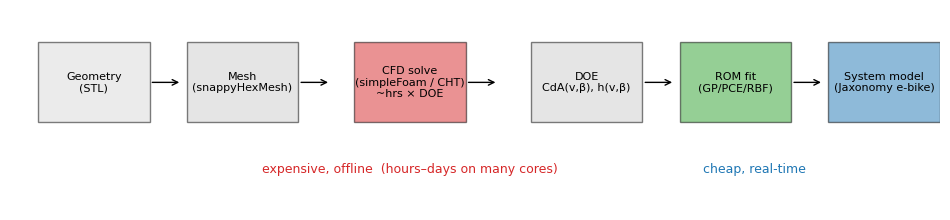

In [7]:
fig, ax = plt.subplots(figsize=(12, 2.6)); ax.axis("off")
stages = [("Geometry\n(STL)", 0.03), ("Mesh\n(snappyHexMesh)", 0.19),
          ("CFD solve\n(simpleFoam / CHT)\n~hrs × DOE", 0.37),
          ("DOE\nCdA(v,β), h(v,β)", 0.56), ("ROM fit\n(GP/PCE/RBF)", 0.72),
          ("System model\n(Jaxonomy e-bike)", 0.88)]
for (label, x), col in zip(stages, ["0.85", "0.8", "tab:red", "0.8", "tab:green", "tab:blue"]):
    ax.add_patch(plt.Rectangle((x, 0.35), 0.12, 0.32, facecolor=col, edgecolor="k", alpha=0.5))
    ax.text(x + 0.06, 0.51, label, ha="center", va="center", fontsize=8)
    if x < 0.85: ax.annotate("", xy=(x + 0.155, 0.51), xytext=(x + 0.12, 0.51), arrowprops=dict(arrowstyle="->"))
ax.text(0.43, 0.15, "expensive, offline  (hours–days on many cores)", ha="center", color="tab:red", fontsize=9)
ax.text(0.80, 0.15, "cheap, real-time", ha="center", color="tab:blue", fontsize=9)
ax.set(xlim=(0, 1), ylim=(0, 0.8)); plt.show()

## 10. Limitations, validation, and alternatives

**Limitations.** (i) **Turbulence-model error** — RANS closures are calibrated,
not exact; separated bluff-body wakes (a rider!) are their weak spot. (ii)
**Mesh dependence** — always run a mesh-independence study. (iii) **Cost** —
millions of cells, hours per case, so CFD-in-the-loop is infeasible (hence the
ROM). (iv) **ROM extrapolation** — a surrogate is only trustworthy inside its
DOE; the GP's σ (Fig 2) tells you where it isn't. (v) **Validation gap** — CFD
must be validated against experiment (wind tunnel, PIV) before you trust the map.

**And one honesty item specific to this notebook.** Every quantitative
"result" above inherits the stand-in's physics; the deliverable of this Part is
the *pipeline* (DOE → fit → validate → Sobol → embed) plus the case skeleton
and backend seam where real CFD plugs in. When the seam is filled: validate the
solver against wind-tunnel data first, re-run the DOE, refit, and only then do
the Sobol splits and coupling numbers become claims.

**Alternatives to CFD.** Wind-tunnel testing (the gold standard for drag);
empirical handbook correlations (when your geometry matches a tabulated one —
what Parts 1 & the stand-in used); potential-flow / panel methods (fast, attached
flows only); XFOIL-class 2-D tools (airfoil sections). CFD earns its cost when
the geometry is novel, the flow is separated/3-D, or you are *optimizing* a shape.

## 11. Exercises

1. **(code)** Add a third DOE factor (rider posture, as a drag multiplier) and
   refit the PCE at order 2. How do the Sobol indices redistribute?
2. **(code)** Use the GP σ field to pick the next 3 CFD points you'd run
   (maximize predicted uncertainty). This is active learning / adaptive DOE.
3. **(concept)** For the battery cooling map you need $h$, not $C_d$. Which
   OpenFOAM solver, which extra region, and which boundary output? (Hint: §3–4.)
4. **(concept)** Draw the preCICE data-exchange diagram for a **two-way transient
   CHT** coupling of the battery pack with the airflow: what crosses the
   interface each step, in which direction, and what makes the scheme implicit?
5. **(open-ended)** Sketch (or, if you have OpenFOAM, run) a mesh-independence
   study for the bluff-body case: how would you decide the mesh is "converged",
   and how does that interact with the $y^+$ target?

## Key takeaways

- CFD solves the **Navier–Stokes field** on a mesh; the DNS→LES→RANS ladder
  trades cost for turbulence fidelity, and RANS closures are the main error
  source.
- CFD is **complementary** to lumped 0-D/1-D models: it **produces** the
  coefficients ($C_dA$, $h$) that the fast system model **consumes**.
- The practical bridge is a **surrogate/ROM** (RBF/GP/PCE) fit to a DOE — GP
  adds uncertainty, PCE adds Sobol sensitivity — dropped into the vehicle model,
  as we did to price a crosswind's range penalty.
- **Co-simulation** ranges from offline one-way (usual) to online two-way tight
  coupling via preCICE (only when the feedback matters). Validate against
  experiment; respect the ROM's domain of validity.

**Series complete.** Parts 2–5 covered optimization, electrochemistry,
multibody, and CFD — four ways to go deeper than a single lumped model, each
feeding results back into the Part-1 e-bike.

## References
- J. H. Ferziger, M. Perić, *Computational Methods for Fluid Dynamics*, Springer.
- F. R. Menter, *Two-equation eddy-viscosity turbulence models*, AIAA J. 32(8), 1994 (k-ω SST).
- H. Jasak et al., *OpenFOAM*; preCICE (Bungartz et al., 2016) for coupled multiphysics.
- I. M. Sobol, *Global sensitivity indices*, 2001.